In [656]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
import scipy.stats as stats



sns.set_style("whitegrid")

In [657]:
df = sns.load_dataset("titanic")
titanic = df.copy()

In [658]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [659]:
titanic.shape

(891, 15)

In [660]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [661]:
print(f"{'Column':<20} | {'Data Type':>10} | {'Has Missing':<12} | {'Missing %':>10}")
print("-" * 65)

for col in titanic.columns:
    has_missing = titanic[col].isna().any()
    missing_pct = titanic[col].isna().mean() * 100

    print(f"{col:<20} | {str(titanic[col].dtype):>10} | {str(has_missing):<12} | {missing_pct:>9.2f}%")

Column               |  Data Type | Has Missing  |  Missing %
-----------------------------------------------------------------
survived             |      int64 | False        |      0.00%
pclass               |      int64 | False        |      0.00%
sex                  |        str | False        |      0.00%
age                  |    float64 | True         |     19.87%
sibsp                |      int64 | False        |      0.00%
parch                |      int64 | False        |      0.00%
fare                 |    float64 | False        |      0.00%
embarked             |        str | True         |      0.22%
class                |   category | False        |      0.00%
who                  |        str | False        |      0.00%
adult_male           |       bool | False        |      0.00%
deck                 |   category | True         |     77.22%
embark_town          |        str | True         |      0.22%
alive                |        str | False        |      0.00%
alon

In [662]:
print(f'Survival Rate: {titanic["survived"].mean():>7.3f}%')
print(f'Average Age: {titanic["age"].mean():>10.3f}')
print(f'Average Fare: {titanic["fare"].mean():>9.3f}')

Survival Rate:   0.384%
Average Age:     29.699
Average Fare:    32.204


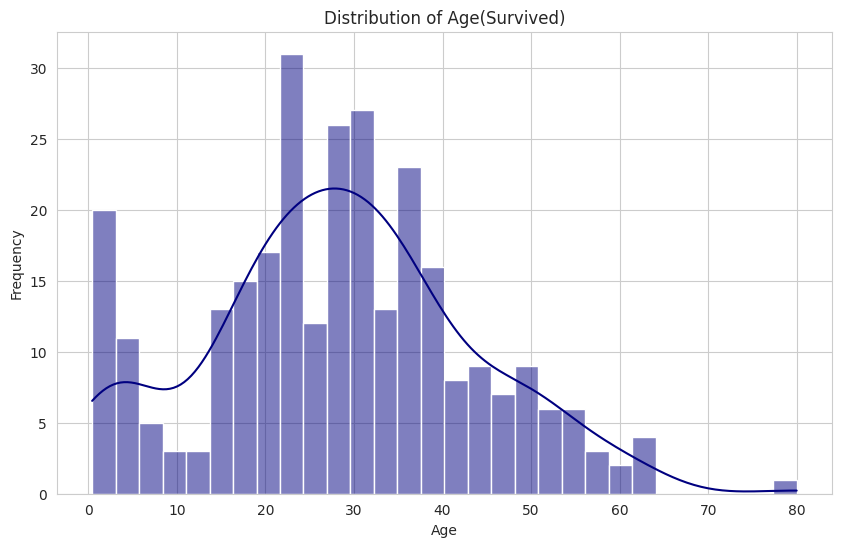

In [663]:
plt.figure(figsize=(10, 6))
sns.histplot(titanic[titanic["survived"] == 1]["age"], bins=30, kde=True, color='navy')
plt.title("Distribution of Age(Survived)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

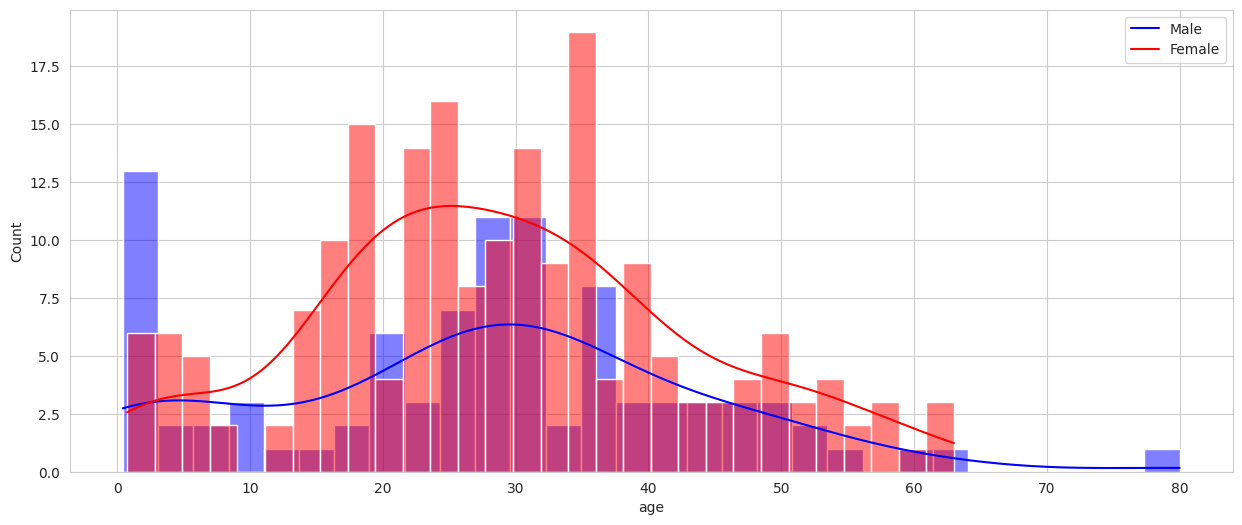

In [664]:
fig, ax = plt.subplots(1, 1, figsize=(15, 6))

sns.histplot(
    titanic[(titanic["survived"] == 1) & (titanic["sex"] == "male")]["age"],
    bins=30,
    kde=True,
    ax=ax,
    color="blue",
    label = 'Male'
)

sns.histplot(
    titanic[(titanic["survived"] == 1) & (titanic["sex"] == "female")]["age"],
    bins=30,
    kde=True,
    ax=ax,
    color="red",
    label = 'Female'
)

plt.legend(labels=["Male", "Female"])

<Axes: xlabel='age', ylabel='Count'>

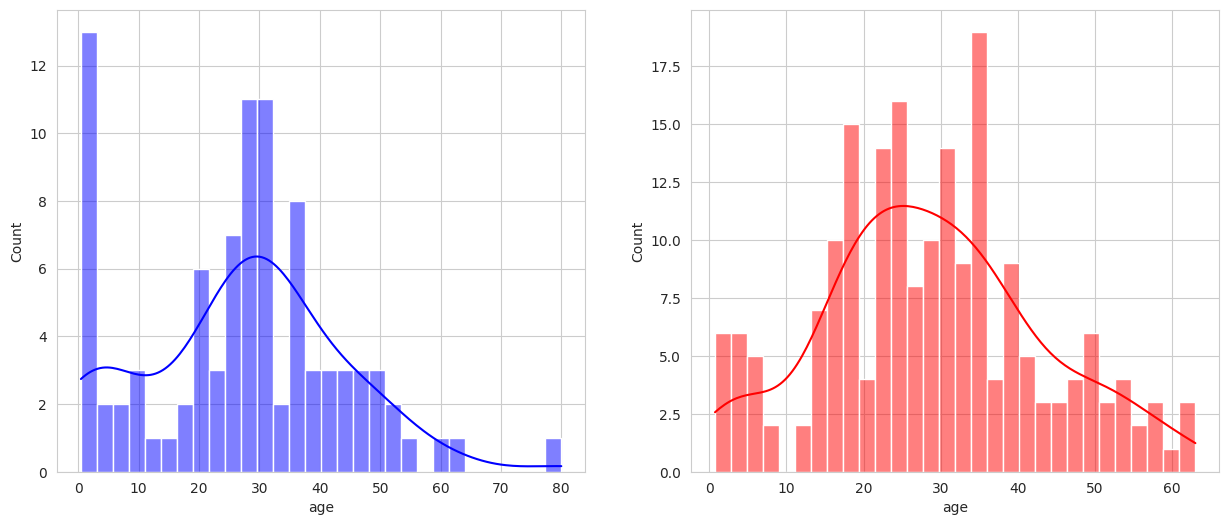

In [665]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(
    titanic[(titanic["survived"] == 1) & (titanic["sex"] == "male")]["age"],
    bins=30,
    kde=True,
    ax=ax[0],
    color="blue",
    label = "Male Survival age rate"
)


sns.histplot(
    titanic[(titanic["survived"] == 1) & (titanic["sex"] == "female")]["age"],
    bins=30,
    kde=True,
    ax=ax[1],
    color="red",
    label = "Female Survival age rate"
)



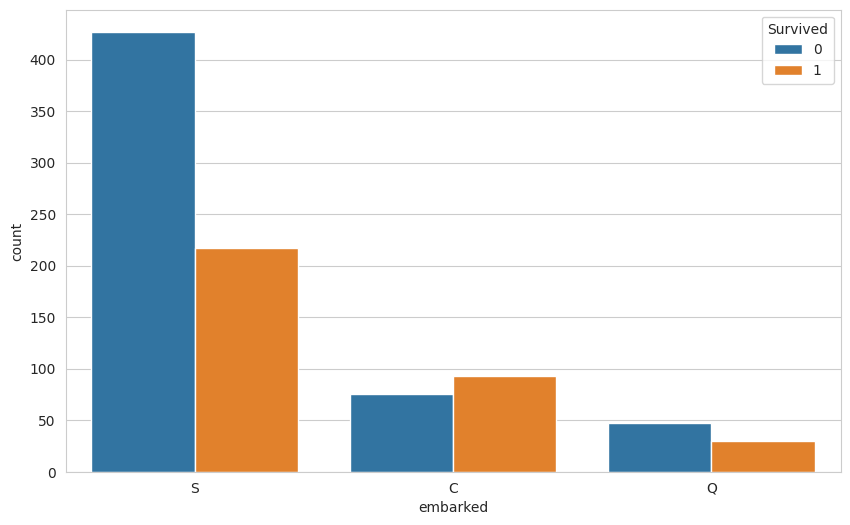

In [666]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=titanic,
    x="embarked",
    hue="survived"
)

plt.legend(title="Survived")
plt.show()

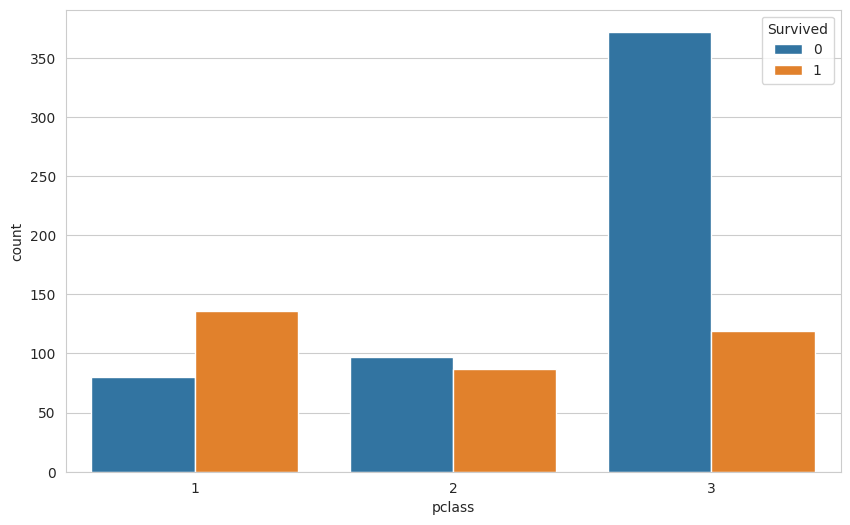

In [667]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=titanic,
    x="pclass",
    hue="survived"
)

plt.legend(title="Survived")
plt.show()

<Axes: xlabel='fare', ylabel='Count'>

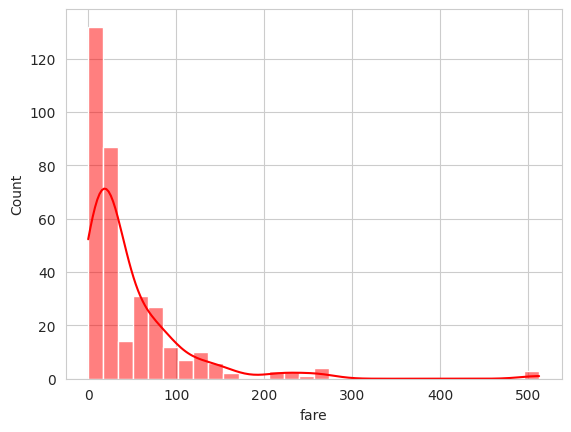

In [668]:
sns.histplot(
    titanic[titanic["survived"] == 1]["fare"],
    bins=30,
    kde=True,
    color="red",
    label = 'Female'
)

In [669]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


The Titanic dataset contains information about passengers such as age, sex, class, and survival status. The dataset consists of several numerical features, including age, fare, and passenger class, as well as categorical features such as sex, embarked location, and class labels.

From the data inspection, it is clear that some columns contain missing values. The most significant missing data appears in the deck column, followed by age and embarked. This suggests that deck may not be very useful for analysis due to the high percentage of missing values, while age may require imputation.

The target variable, survived, is binary and slightly imbalanced. The survival rate is around 38%, meaning that most passengers did not survive the disaster.

The age distribution shows that most passengers were young adults, with fewer elderly individuals. The distribution is slightly skewed, indicating the presence of some extreme values.

The analysis of survival rates by sex reveals a strong pattern: females had a significantly higher survival rate compared to males. This suggests that gender played an important role in survival, likely due to evacuation priorities.

In [670]:
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])

titanic.drop(columns=['deck'], inplace=True)

In [671]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    str     
 12  alive        891 non-null    str     
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(5)
memory usage: 99.0 KB


In [672]:
titanic.embarked.unique()

<ArrowStringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [673]:
lab_encoder = LabelEncoder()
ohe = OneHotEncoder(drop='first', sparse_output=False)

titanic['sex'] = lab_encoder.fit_transform(titanic['sex'])

encoded = ohe.fit_transform(titanic[['embarked']])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['embarked']),
    index=titanic.index
)

titanic = pd.concat([titanic, encoded_df], axis=1)

In [674]:
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['is_alone'] = titanic['family_size'] == 1

In [675]:
titanic.drop(columns=['alive', 'who', 'adult_male', 'embark_town', 'class', 'alone'], 
             inplace=True)

In [676]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,embarked_Q,embarked_S,family_size,is_alone
0,0,3,1,22.0,1,0,7.2500,S,0.0,1.0,2,False
1,1,1,0,38.0,1,0,71.2833,C,0.0,0.0,2,False
2,1,3,0,26.0,0,0,7.9250,S,0.0,1.0,1,True
3,1,1,0,35.0,1,0,53.1000,S,0.0,1.0,2,False
4,0,3,1,35.0,0,0,8.0500,S,0.0,1.0,1,True


In [677]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    int64  
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     891 non-null    str    
 8   embarked_Q   891 non-null    float64
 9   embarked_S   891 non-null    float64
 10  family_size  891 non-null    int64  
 11  is_alone     891 non-null    bool   
dtypes: bool(1), float64(4), int64(6), str(1)
memory usage: 78.4 KB


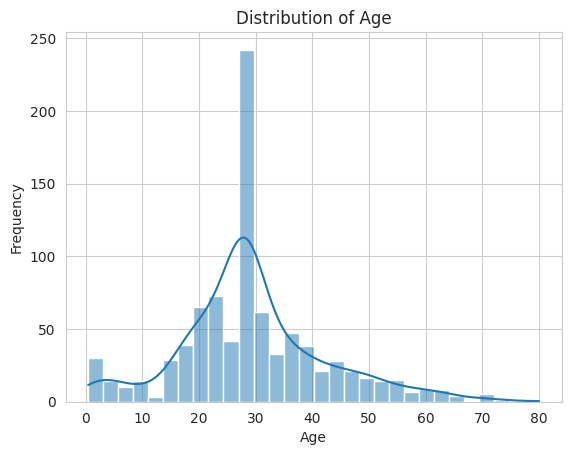

In [678]:
sns.histplot(titanic['age'], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

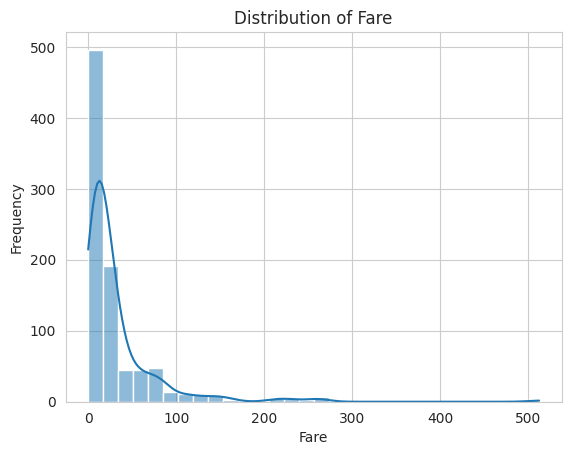

In [679]:
sns.histplot(titanic['fare'], bins=30, kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

In [680]:
num_cols = ['age', 'fare']
std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()

titanic_std = titanic.copy()
titanic_mm = titanic.copy()

titanic_std[num_cols] = std_scaler.fit_transform(titanic[num_cols])
titanic_mm[num_cols] = mm_scaler.fit_transform(titanic[num_cols])

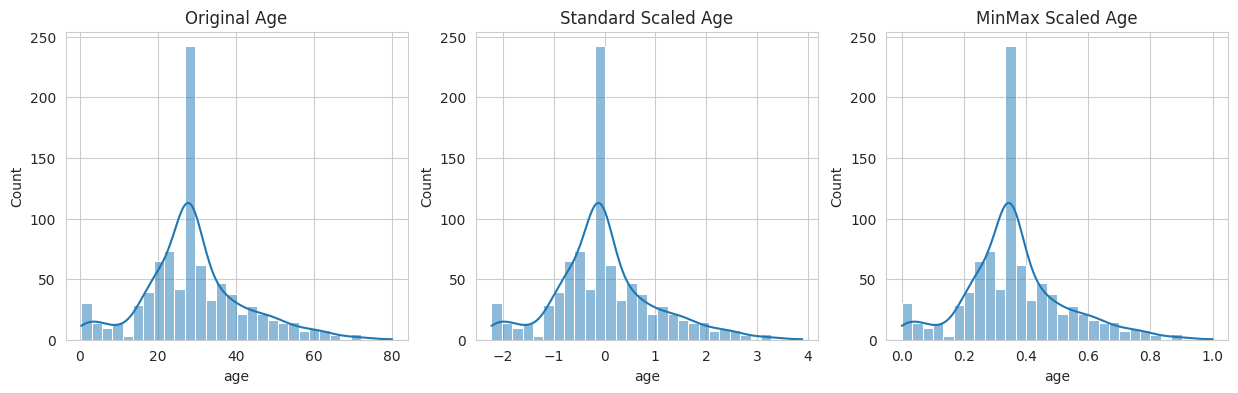

In [681]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(titanic['age'], kde=True)
plt.title("Original Age")

plt.subplot(1, 3, 2)
sns.histplot(titanic_std['age'], kde=True)
plt.title("Standard Scaled Age")

plt.subplot(1, 3, 3)
sns.histplot(titanic_mm['age'], kde=True)
plt.title("MinMax Scaled Age")

plt.show()

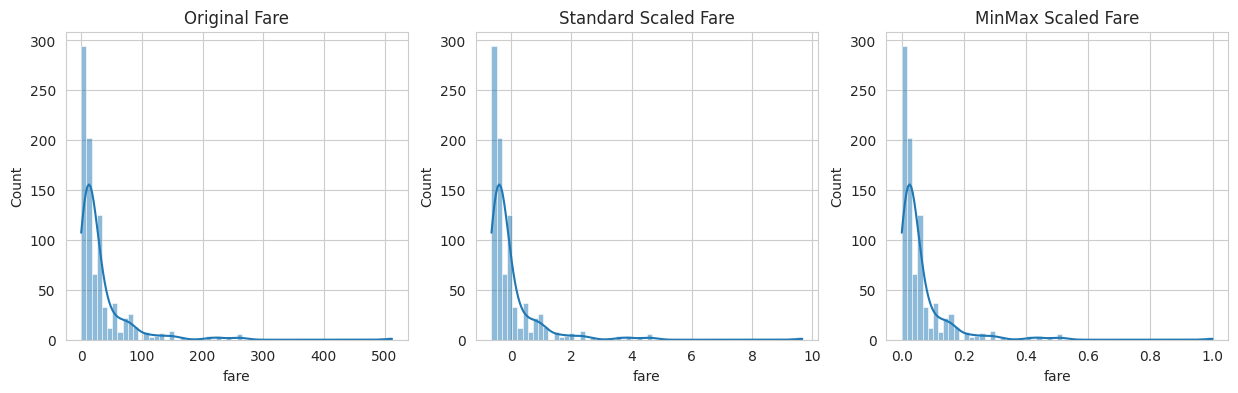

In [682]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(titanic['fare'], kde=True)
plt.title("Original Fare")

plt.subplot(1, 3, 2)
sns.histplot(titanic_std['fare'], kde=True)
plt.title("Standard Scaled Fare")

plt.subplot(1, 3, 3)
sns.histplot(titanic_mm['fare'], kde=True)
plt.title("MinMax Scaled Fare")

plt.show()

StandardScaler transforms the data so that it has a mean of 0 and a standard deviation of 1. It centers the data and scales it based on how far each value is from the mean. This method is useful when the data follows a roughly normal distribution and is commonly used in algorithms like logistic regression and support vector machines. However, it is sensitive to outliers because extreme values can significantly affect the mean and standard deviation.

MinMaxScaler, on the other hand, rescales the data to a fixed range, usually between 0 and 1. It preserves the original distribution shape but compresses all values into this range. This method is useful when you need bounded values, such as in neural networks or distance-based models. However, it is highly sensitive to outliers, as extreme values will squeeze the rest of the data into a smaller range.

StandardScaler standardizes data based on statistical properties (mean and variance), while MinMaxScaler normalizes data into a fixed range. The choice between them depends on the model being used and the presence of outliers in the dataset.

In [683]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,embarked_Q,embarked_S,family_size,is_alone
0,0,3,1,22.0,1,0,7.2500,S,0.0,1.0,2,False
1,1,1,0,38.0,1,0,71.2833,C,0.0,0.0,2,False
2,1,3,0,26.0,0,0,7.9250,S,0.0,1.0,1,True
3,1,1,0,35.0,1,0,53.1000,S,0.0,1.0,2,False
4,0,3,1,35.0,0,0,8.0500,S,0.0,1.0,1,True


In [684]:
corr_cols = [
    'survived', 'pclass', 'sex', 'age',
    'sibsp', 'parch', 'fare',
    'embarked_Q', 'embarked_S',
    'family_size', 'is_alone'
]

corr = titanic[corr_cols].corr()
corr

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,family_size,is_alone
survived,1.000000,-0.338481,-0.543351,-0.064910,-0.035322,0.081629,0.257307,0.003650,-0.149683,0.016639,-0.203367
pclass,-0.338481,1.000000,0.131900,-0.339898,0.083081,0.018443,-0.549500,0.221009,0.074053,0.065997,0.135207
sex,-0.543351,0.131900,1.000000,0.081163,-0.114631,-0.245489,-0.182333,-0.074115,0.119224,-0.200988,0.303646
age,-0.064910,-0.339898,0.081163,1.000000,-0.233296,-0.172482,0.096688,-0.031415,-0.006729,-0.245619,0.171647
sibsp,-0.035322,0.083081,-0.114631,-0.233296,1.000000,0.414838,0.159651,-0.026354,0.068734,0.890712,-0.584471
parch,0.081629,0.018443,-0.245489,-0.172482,0.414838,1.000000,0.216225,-0.081228,0.060814,0.783111,-0.583398
fare,0.257307,-0.549500,-0.182333,0.096688,0.159651,0.216225,1.000000,-0.117216,-0.162184,0.217138,-0.271832
embarked_Q,0.003650,0.221009,-0.074115,-0.031415,-0.026354,-0.081228,-0.117216,1.000000,-0.499421,-0.058592,0.086464
embarked_S,-0.149683,0.074053,0.119224,-0.006729,0.068734,0.060814,-0.162184,-0.499421,1.000000,0.077359,0.029074
family_size,0.016639,0.065997,-0.200988,-0.245619,0.890712,0.783111,0.217138,-0.058592,0.077359,1.000000,-0.690922


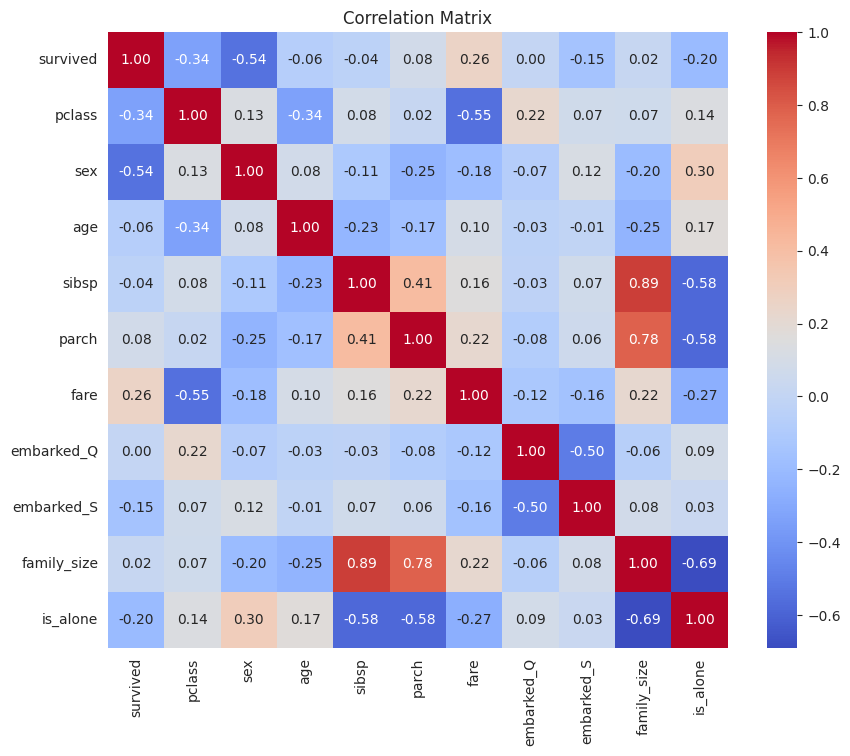

In [685]:
plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [686]:
corr_with_target = titanic.corr(numeric_only=True)['survived'].sort_values(ascending=False)

print(corr_with_target.to_frame(name="correlation_with_survived"))

             correlation_with_survived
survived                      1.000000
fare                          0.257307
parch                         0.081629
family_size                   0.016639
embarked_Q                    0.003650
sibsp                        -0.035322
age                          -0.064910
embarked_S                   -0.149683
is_alone                     -0.203367
pclass                       -0.338481
sex                          -0.543351


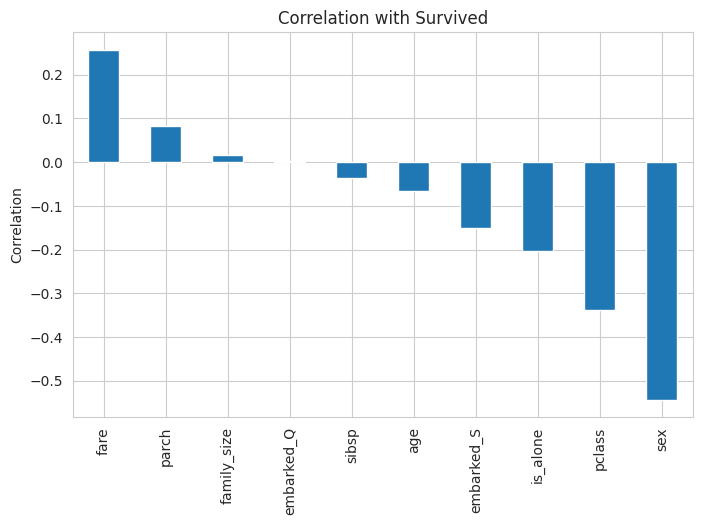

In [687]:
corr_with_target.drop('survived').plot(kind='bar', figsize=(8, 5))

plt.title("Correlation with Survived")
plt.ylabel("Correlation")
plt.show()

Correlations:
- Strong:
    - Sex(-0.54) - males are less likely to survive. 
    - Pclass(-0.34) - higher class number => lower survival

- Moderate:
    - Fare(0.26) - higher fare => higher survival 
    - is_alone(-0.20) - alone passengers are less likely to survive

- Weak/negligible:
    - age(-0.06)
    - sibsp, parch, family_size => almost no impact
    - embarked_* - minimal

In [688]:
features_1 = ['sex', 'pclass', 'fare', 'is_alone', 'embarked_S', 'embarked_Q']
features_2 = ['sex', 'pclass', 'fare', 'is_alone', 'age']


Two feature sets were created based on correlation analysis and domain knowledge.

The first feature set, features_1, includes sex, pclass, fare, is_alone, embarked_S, and embarked_Q. This selection strictly follows the correlation-based approach, where features with an absolute correlation greater than or equal to 0.1 with the target variable are retained. The inclusion of embarked_S and embarked_Q captures the potential effect of embarkation location on survival, even though their correlations are relatively weaker compared to other variables. This set prioritizes a more data-driven and objective selection process.

The second feature set, features_2, includes sex, pclass, fare, is_alone, and age. In this case, age is included despite having a low linear correlation with survival. This decision is based on domain knowledge, as age is known to have a non-linear relationship with survival outcomes, particularly with children having higher survival rates. Therefore, this feature set balances statistical evidence with real-world understanding.

In [689]:
titanic_1 = titanic[features_1]
titanic_2 = titanic[features_2]

In [690]:
scaler1 = StandardScaler()
scaler2 = StandardScaler()

X1_scaled = scaler1.fit_transform(titanic_1)
X2_scaled = scaler2.fit_transform(titanic_2)
pca1 = PCA(n_components=2)
X1_pca = pca1.fit_transform(X1_scaled)

pca2 = PCA(n_components=2)
X2_pca = pca2.fit_transform(X2_scaled)

y = titanic['survived']

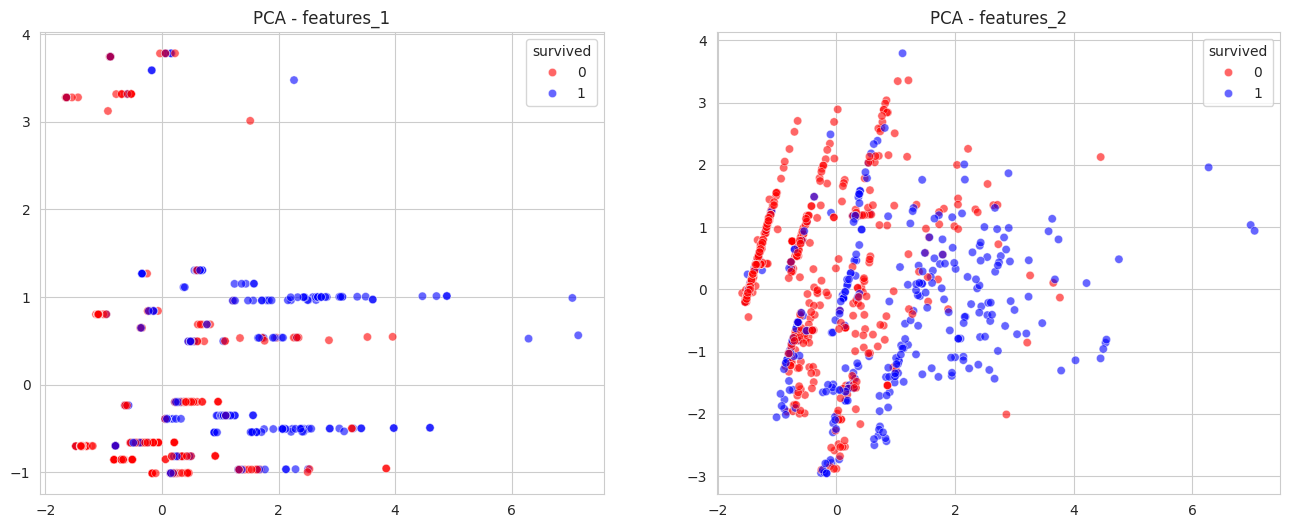

In [691]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x=X1_pca[:, 0],
    y=X1_pca[:, 1],
    hue=titanic['survived'],
    palette={0: "red", 1: "blue"},
    alpha=0.6
)
plt.title("PCA - features_1")

plt.subplot(1, 2, 2)
sns.scatterplot(
    x=X2_pca[:, 0],
    y=X2_pca[:, 1],
    hue=titanic['survived'],
    palette={0: "red", 1: "blue"},
    alpha=0.6
)
plt.title("PCA - features_2")

plt.show()

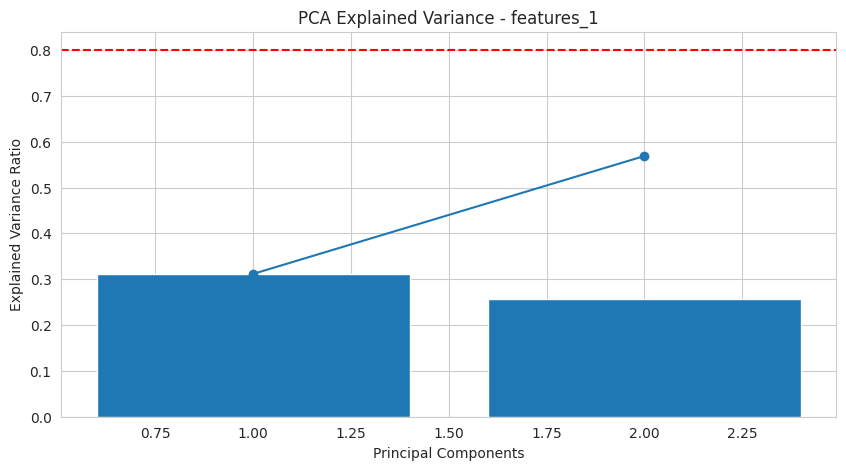

In [692]:
explained_var = pca1.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 5))

plt.bar(range(1, len(explained_var) + 1), explained_var)
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')

plt.axhline(y=0.80, color='r', linestyle='--')

plt.title("PCA Explained Variance - features_1")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")

plt.show()

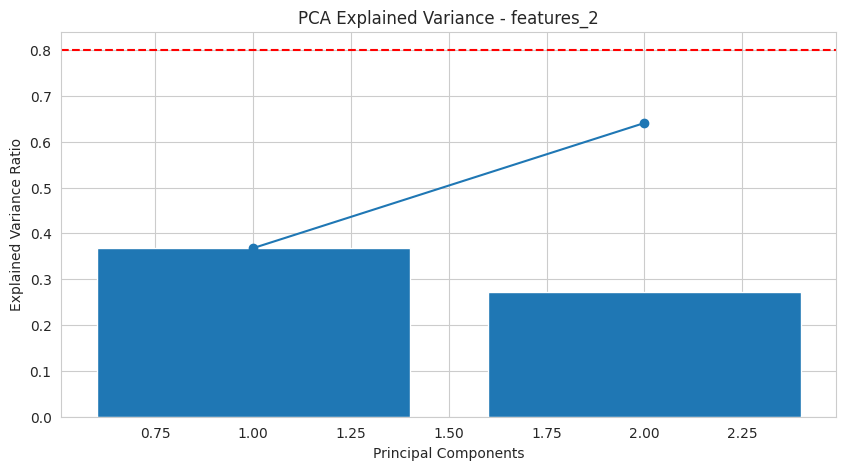

In [693]:
explained_var = pca2.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 5))

plt.bar(range(1, len(explained_var) + 1), explained_var)
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')

plt.axhline(y=0.80, color='r', linestyle='--')

plt.title("PCA Explained Variance - features_2")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")

plt.show()

In [694]:
def pca_80(X):
    pca = PCA()
    pca.fit(X)
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    return np.argmax(cum_var >= 0.80) + 1

print('features_1:', pca_80(X1_scaled))
print('features_2:', pca_80(X2_scaled))

features_1: 4
features_2: 4


Principal Component Analysis was applied to explore whether the dataset can be effectively reduced in dimensionality while preserving most of the information. The results show that a small number of components is sufficient to capture at least 80% of the variance, indicating that the dataset has moderate redundancy among features.

However, when visualizing the data in two principal components, there is no clear separation between survivors and non-survivors. This suggests that survival is not linearly separable in reduced dimensional space.

Comparing two feature sets, PCA results remain similar, with only minor differences in variance distribution. This indicates that adding features such as age does not significantly improve linear structure in the data.